# Understanding Genetic Traits: From Simple to Complex

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

This notebook helps us visualize how different numbers of genes contribute to a trait, and how the environment can influence it. We're simulating traits in a population of $N = 500$ individuals.

The cell below defines a set of function for making the simulation.

You don't need to understand the details of these functions, so you can skip ahead to the next cell.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")


def simulate_polygenic_trait(n_loci, N, p, env_sd, rng):
    """
    Simulate a polygenic trait with environmental noise.
    
    Parameters:
    - n_loci: number of loci
    - N: number of individuals
    - p: frequency of "effect" allele
    - env_sd: environmental standard deviation
    - rng: numpy random number generator
    
    Returns:
    - geno: genotype array
    - phenotype: phenotype array
    """
    geno = rng.binomial(2, p, size=(N, n_loci))
    per_locus_effect = 1.0 / np.sqrt(n_loci)
    genetic_value = per_locus_effect * geno.sum(axis=1)
    env_noise = rng.normal(0, env_sd, size=N)
    phenotype = genetic_value + env_noise
    return geno, phenotype


def simulate_mendelian_trait(N, p, rng):
    """
    Simulate a Mendelian trait with dominant/recessive inheritance.
    
    Parameters:
    - N: number of individuals
    - p: frequency of dominant allele
    - rng: numpy random number generator
    
    Returns:
    - df_mendelian: DataFrame with genotype and phenotype columns
    """
    geno_mendelian = rng.binomial(2, p, size=N)
    
    geno_labels = np.where(
        geno_mendelian == 2, "AA",
        np.where(geno_mendelian == 1, "Aa", "aa")
    )
    
    pheno_mendelian = np.where(geno_mendelian >= 1, "Dominant", "Recessive")
    
    df_mendelian = pd.DataFrame({
        "Genotype": geno_labels,
        "Phenotype": pheno_mendelian
    })
    
    return df_mendelian


def print_mendelian_summary(df_mendelian):
    """
    Print summary statistics for Mendelian trait.
    
    Parameters:
    - df_mendelian: DataFrame with phenotype column
    """
    phenotype_counts = df_mendelian["Phenotype"].value_counts()
    
    dom = phenotype_counts.get("Dominant", 0)
    rec = phenotype_counts.get("Recessive", 0)
    
    print("Mendelian phenotypic class counts:")
    print(phenotype_counts.to_string())
    
    ratio = dom / rec if rec > 0 else np.nan
    print(f"Ratio Dominant:Recessive = {dom}:{rec} (≈ {ratio:.2f}:1)")


def print_quantitative_summary(pheno1, pheno2, pheno3):
    """
    Print summary statistics for quantitative traits.
    
    Parameters:
    - pheno1, pheno2, pheno3: phenotype arrays
    """
    print("\nQuantitative means:", np.mean(pheno1), np.mean(pheno2), np.mean(pheno3))
    print("Quantitative SDs:", np.std(pheno1), np.std(pheno2), np.std(pheno3))


def plot_mendelian_and_quantitative_traits(df_mendelian, pheno1, pheno2, pheno3, 
                                           geno_sum1, geno_sum2, geno_sum3):
    """
    Create comprehensive plot showing Mendelian and quantitative traits.
    
    Parameters:
    - df_mendelian: DataFrame with Mendelian genotype and phenotype
    - pheno1, pheno2, pheno3: phenotype arrays for 1, 2, 3 genes
    - geno_sum1, geno_sum2, geno_sum3: sum of '+' alleles for each trait
    """
    fig = plt.figure(figsize=(16, 12))

    # (A) Mendelian bar plot: genotype counts
    ax1 = plt.subplot2grid((3, 3), (0, 0))
    sns.countplot(data=df_mendelian, x="Genotype", hue="Genotype", ax=ax1,
                  order=["AA", "Aa", "aa"], palette="pastel", legend=False)
    ax1.set_title("Mendelian genotypes (AA, Aa, aa)")
    ax1.set_ylabel("Count")

    # (B) Mendelian bar plot: phenotype counts
    ax2 = plt.subplot2grid((3, 3), (0, 1))
    sns.countplot(data=df_mendelian, x="Phenotype", hue="Phenotype", ax=ax2,
                  order=["Dominant", "Recessive"], palette="pastel", legend=False)
    ax2.set_title("Mendelian phenotypes (2 classes)")
    ax2.set_ylabel("Count")

    # (C) Annotation panel
    ax_annot = plt.subplot2grid((3, 3), (0, 2))
    ax_annot.axis("off")
    ax_annot.text(
        0, 0.5,
        "Top: discrete Mendelian trait\n"
        "(3 genotypes → 2 phenotypic classes).\n\n"
        "Bottom: quantitative traits\n"
        "controlled by 1, 2, and 3 genes,\n"
        "shown as histograms and\n"
        "genotype–phenotype scatters.",
        fontsize=11, va="center"
    )

    # (D) Histograms of quantitative traits
    ax3 = plt.subplot2grid((3, 3), (1, 0))
    sns.histplot(pheno1, kde=False, bins=20, color="tab:blue", ax=ax3)
    ax3.set_title("Quantitative trait (1 gene)")
    ax3.set_xlabel("Trait value")
    ax3.set_ylabel("Count")

    ax4 = plt.subplot2grid((3, 3), (1, 1))
    sns.histplot(pheno2, kde=False, bins=20, color="tab:orange", ax=ax4)
    ax4.set_title("Quantitative trait (2 genes)")
    ax4.set_xlabel("Trait value")
    ax4.set_ylabel("Count")

    ax5 = plt.subplot2grid((3, 3), (1, 2))
    sns.histplot(pheno3, kde=False, bins=20, color="tab:green", ax=ax5)
    ax5.set_title("Quantitative trait (3 genes)")
    ax5.set_xlabel("Trait value")
    ax5.set_ylabel("Count")

    # (E) Genotype–phenotype scatter plots
    ax6 = plt.subplot2grid((3, 3), (2, 0))
    ax6.scatter(geno_sum1, pheno1, alpha=0.6, color="tab:blue")
    ax6.set_title("1 gene: genotype–phenotype")
    ax6.set_xlabel("Number of '+' alleles")
    ax6.set_ylabel("Trait value")

    ax7 = plt.subplot2grid((3, 3), (2, 1))
    ax7.scatter(geno_sum2, pheno2, alpha=0.6, color="tab:orange")
    ax7.set_title("2 genes: genotype–phenotype")
    ax7.set_xlabel("Total '+' alleles")
    ax7.set_ylabel("Trait value")

    ax8 = plt.subplot2grid((3, 3), (2, 2))
    ax8.scatter(geno_sum3, pheno3, alpha=0.6, color="tab:green")
    ax8.set_title("3 genes: genotype–phenotype")
    ax8.set_xlabel("Total '+' alleles")
    ax8.set_ylabel("Trait value")

    plt.tight_layout()
    plt.show()


def generate_mendelian_quantitative_comparison(N=500, p=0.5, env_sd1=0.2, env_sd2=0.2, 
                                               env_sd3=0.2, seed=42):
    """
    Main orchestration function: simulate and visualize Mendelian and quantitative traits.
    
    Parameters:
    - N: number of individuals
    - p: frequency of effect allele
    - env_sd1, env_sd2, env_sd3: environmental SDs for 1, 2, 3 gene traits
    - seed: random seed for reproducibility
    """
    rng = np.random.default_rng(seed)
    
    # Simulate Mendelian trait
    df_mendelian = simulate_mendelian_trait(N, p, rng)
    
    # Simulate quantitative traits
    geno1, pheno1 = simulate_polygenic_trait(1, N, p, env_sd1, rng)
    geno2, pheno2 = simulate_polygenic_trait(2, N, p, env_sd2, rng)
    geno3, pheno3 = simulate_polygenic_trait(3, N, p, env_sd3, rng)
    
    # Calculate genetic scores
    geno_sum1 = geno1.sum(axis=1)
    geno_sum2 = geno2.sum(axis=1)
    geno_sum3 = geno3.sum(axis=1)
    
    # Generate plots
    plot_mendelian_and_quantitative_traits(
        df_mendelian, pheno1, pheno2, pheno3, 
        geno_sum1, geno_sum2, geno_sum3
    )
    
    # Print summaries
    print_mendelian_summary(df_mendelian)
    print_quantitative_summary(pheno1, pheno2, pheno3)


The main function is `generate_trait_simulation_plots`, an example of how to use it is shown below.

#### Key Concepts:

- **Mendelian Traits (1 gene)**: These are traits determined by a single gene. Think of simple inheritance patterns like Mendel's pea plants. In our simulation, `n_loci=1` represents this.

- **Polygenic Traits (Multiple genes)**: These traits are influenced by many genes, each contributing a small effect. Most complex human traits, like height or intelligence, are polygenic. Our simulations with `n_loci=2` and  `n_loci=3` model increasingly polygenic traits.

- **Alleles and Genetic Score:** Each gene has different versions called alleles. We're tracking a 'plus' (+) allele which contributes to the trait. Your 'genetic score' is simply the total number of these '+' alleles you have across all the genes we're considering.

- **Environmental Noise (env_sd)**: In real life, traits aren't just about genes; the environment also plays a role. `env_sd` represents how much random environmental variation is added to the genetic effect. A low `env_sd` means the environment has little impact, while a high `env_sd` means it has a significant impact.

#### What the Plots Show:

- **Individual vs. Trait**: This scatter plot shows the trait value for each of our 500 simulated individuals. It gives you a raw look at the variation in the trait across the population.

- **Trait Distributions**: These histograms show the overall shape of the trait values in the population. For single-gene traits with no environmental noise, you'll see distinct 'classes' of phenotypes. As more genes are added, or environmental noise increases, the distribution tends to become more continuous and bell-shaped.

- **Genetic Score vs. Trait**: This crucial plot shows how your genetic score (number of '+' alleles) relates to your actual trait value. For Mendelian traits with no environmental noise, there's a perfect, clear relationship. As environment comes into play, this relationship becomes fuzzier.

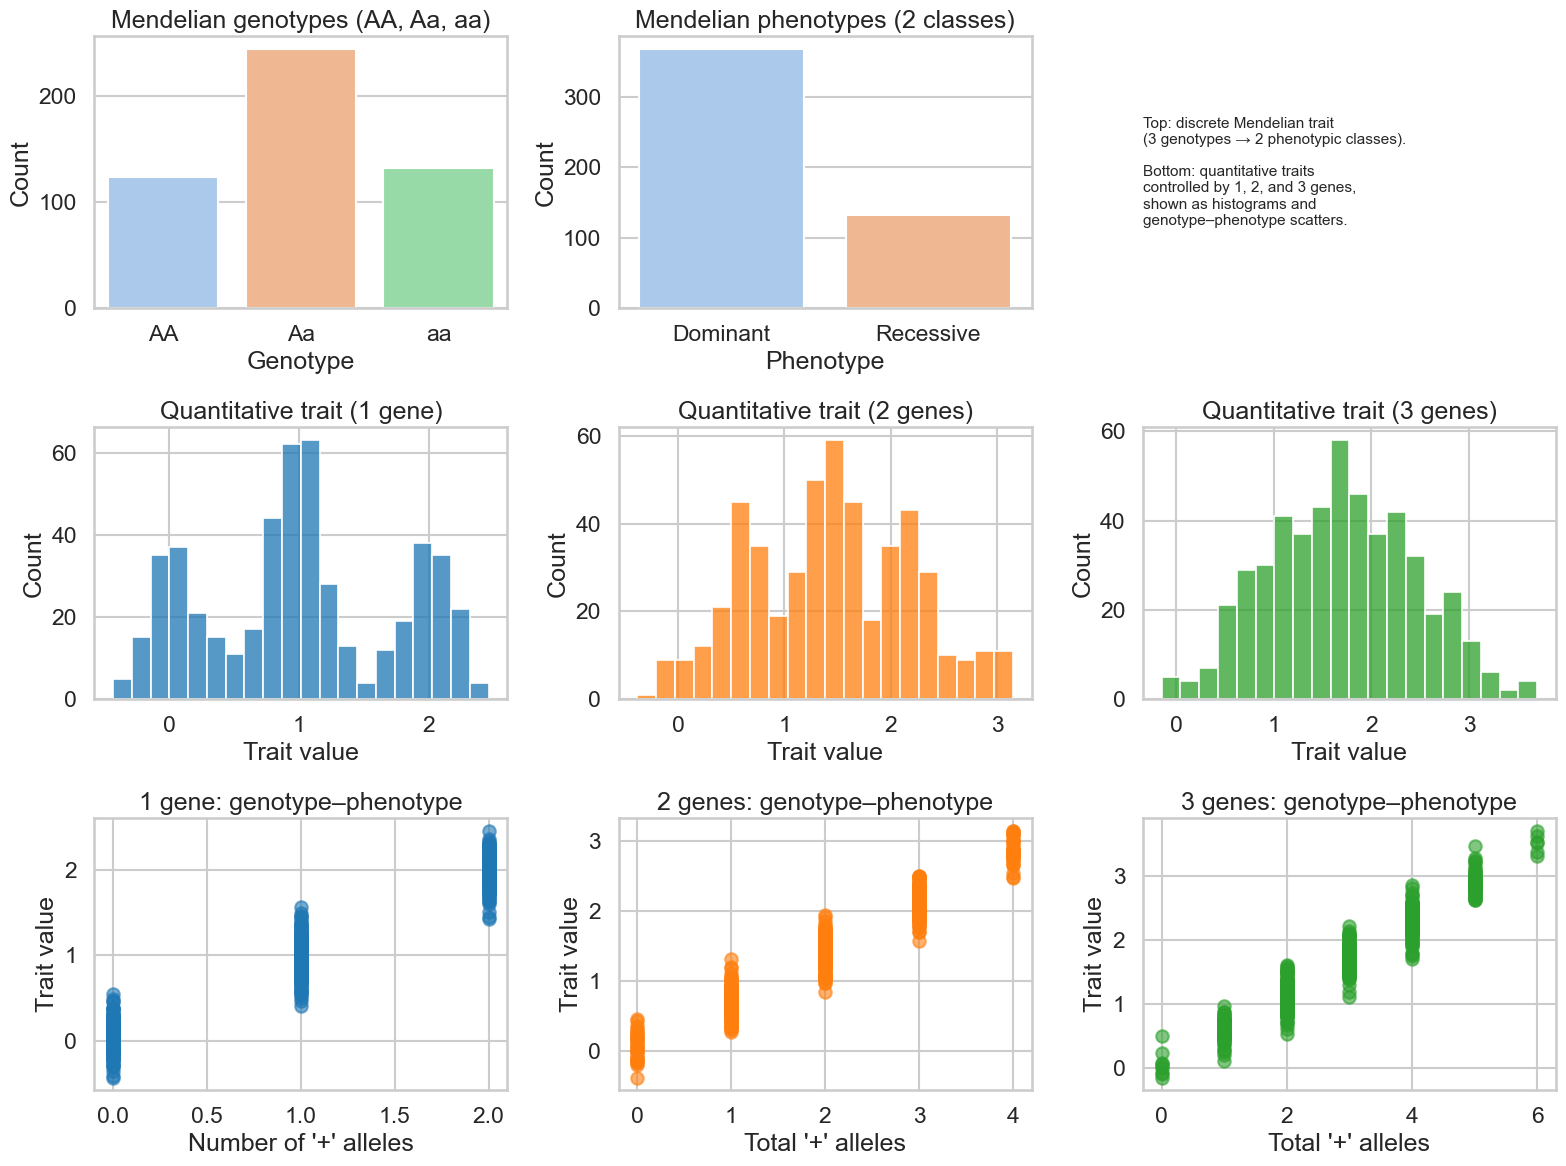

Mendelian phenotypic class counts:
Phenotype
Dominant     368
Recessive    132
Ratio Dominant:Recessive = 368:132 (≈ 2.79:1)

Quantitative means: 1.0082470180067222 1.4331142971547959 1.6988601109688748
Quantitative SDs: 0.7361215533808997 0.7504735313164385 0.7478658519882052


In [12]:
# Core parameters
N = 500
p = 0.5

# Environmental SD per gene category
env_sd1 = 0.2    # environmental SD for 1-gene quantitative trait
env_sd2 = 0.2    # environmental SD for 2-gene quantitative trait
env_sd3 = 0.2    # environmental SD for 3-gene quantitative trait
n_loci = (1, 2, 3)

# Run the simulation
generate_mendelian_quantitative_comparison(N=N, p=p, env_sd1=env_sd1, env_sd2=env_sd2, env_sd3=env_sd3)

## Your Turn:

Looking at the 1-gene trait (Mendelian) and the summary table of its phenotypic classes, how do you think changing the sample size ($N$) from 500 to, say, 50 or 5000 would affect the sampling error in the observed ratios of these phenotypic classes? What might you expect to see if you ran the simulation with a much smaller or much larger number of individuals?